<a href="https://colab.research.google.com/github/dewshishir/new-practice/blob/main/building_segmentation_good_one.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install segmentation-models-pytorch pytorch-lightning

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 857.3/857.3 kB 58.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 983.2/983.2 kB 62.1 MB/s eta 0:00:00


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import os
import cv2
import numpy as np
import torch
import torch.nn as nn
import segmentation_models_pytorch as smp
import pytorch_lightning as pl
from torch.utils.data import Dataset, DataLoader
from sklearn.model_selection import train_test_split

In [ ]:
IMAGE_DIR = "/content/drive/MyDrive/building_dataset/images"
MASK_DIR  = "/content/drive/MyDrive/building_dataset/masks"

In [ ]:
class BuildingDataset(Dataset):

    def __init__(self, image_dir, mask_dir, file_list):
        self.image_dir = image_dir
        self.mask_dir = mask_dir
        self.file_list = file_list

    def __len__(self):
        return len(self.file_list)

    def __getitem__(self, idx):
        filename = self.file_list[idx]

        image = cv2.imread(os.path.join(self.image_dir, filename))
        image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
        image = cv2.resize(image, (512, 512))

        mask = cv2.imread(os.path.join(self.mask_dir, filename), 0)
        mask = cv2.resize(mask, (512, 512), interpolation=cv2.INTER_NEAREST)

        image = torch.tensor(image).permute(2,0,1).float() / 255.0
        mask  = torch.tensor(mask).unsqueeze(0).float() / 255.0

        return image, mask

In [ ]:
all_images = os.listdir(IMAGE_DIR)

train_imgs, val_imgs = train_test_split(
    all_images, test_size=0.2, random_state=42
)

train_loader = DataLoader(
    BuildingDataset(IMAGE_DIR, MASK_DIR, train_imgs),
    batch_size=4,
    shuffle=True,
    num_workers=2
)

val_loader = DataLoader(
    BuildingDataset(IMAGE_DIR, MASK_DIR, val_imgs),
    batch_size=4,
    shuffle=False,
    num_workers=2
)

In [ ]:
class SegModel(pl.LightningModule):

    def __init__(self):
        super().__init__()

        self.model = smp.Unet(
            encoder_name="efficientnet-b3",
            encoder_weights="imagenet",
            in_channels=3,
            classes=1,
            activation=None
        )

        self.dice_loss = smp.losses.DiceLoss(mode='binary', from_logits=True)
        self.bce_loss = nn.BCEWithLogitsLoss()

    def forward(self, x):
        return self.model(x)

    def training_step(self, batch, batch_idx):
        images, masks = batch
        preds = self(images)
        loss = self.bce_loss(preds, masks) + self.dice_loss(preds, masks)

        self.log("train_loss", loss)
        return loss

    def validation_step(self, batch, batch_idx):
        images, masks = batch
        preds = self(images)

        loss = self.bce_loss(preds, masks) + self.dice_loss(preds, masks)

        preds = torch.sigmoid(preds)
        preds = (preds > 0.5).float()

        intersection = (preds * masks).sum()
        union = preds.sum() + masks.sum() - intersection
        iou = intersection / (union + 1e-7)

        self.log("val_loss", loss, prog_bar=True)
        self.log("val_iou", iou, prog_bar=True)

        return loss

    def configure_optimizers(self):
        optimizer = torch.optim.Adam(self.parameters(), lr=1e-4)

        scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
            optimizer,
            mode="min",
            patience=5,
            factor=0.5
        )

        return {
            "optimizer": optimizer,
            "lr_scheduler": {
                "scheduler": scheduler,
                "monitor": "val_loss"
            }
        }

In [ ]:
from pytorch_lightning.callbacks import EarlyStopping, ModelCheckpoint

early_stop = EarlyStopping(
    monitor="val_loss",
    patience=10,
    mode="min"
)

checkpoint = ModelCheckpoint(
    monitor="val_loss",
    mode="min",
    save_top_k=1
)

trainer = pl.Trainer(
    max_epochs=100,
    accelerator="auto",
    callbacks=[early_stop, checkpoint]
)

INFO:pytorch_lightning.utilities.rank_zero:GPU available: True (cuda), used: True
INFO:pytorch_lightning.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO:pytorch_lightning.utilities.rank_zero:💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.


In [ ]:
model = SegModel()
trainer.fit(model, train_loader, val_loader)

INFO:pytorch_lightning.accelerators.cuda:LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


┏━━━┳━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━┳━━━━━━━┳━━━━━━━┓
┃   ┃ Name      ┃ Type              ┃ Params ┃ Mode  ┃ FLOPs ┃
┡━━━╇━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━╇━━━━━━━╇━━━━━━━┩
│ 0 │ model     │ Unet              │ 13.2 M │ train │     0 │
│ 1 │ dice_loss │ DiceLoss          │      0 │ train │     0 │
│ 2 │ bce_loss  │ BCEWithLogitsLoss │      0 │ train │     0 │
└───┴───────────┴───────────────────┴────────┴───────┴───────┘

Trainable params: 13.2 M                                                                                           
Non-trainable params: 0                                                                                            
Total params: 13.2 M                                                                                               
Total estimated model params size (MB): 52                                                                         
Modules in train mode: 475                                                                                         
Modules in eval mode: 0                                                                                            
Total FLOPs: 0

Output()

/usr/local/lib/python3.12/dist-packages/pytorch_lightning/utilities/_pytree.py:21: `isinstance(treespec, LeafSpec)`
is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.

/usr/local/lib/python3.12/dist-packages/pytorch_lightning/loops/fit_loop.py:317: The number of training batches 
(28) is smaller than the logging interval Trainer(log_every_n_steps=50). Set a lower value for log_every_n_steps if
you want to see logs for the training epoch.

In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = SegModel.load_from_checkpoint(
    "lightning_logs/version_1/checkpoints/epoch=78-step=2212.ckpt"
)

model.to(device)
model.eval()

SegModel(
  (model): Unet(
    (encoder): EfficientNetEncoder(
      (_conv_stem): Conv2dStaticSamePadding(
        3, 40, kernel_size=(3, 3), stride=(2, 2), bias=False
        (static_padding): ZeroPad2d((0, 1, 0, 1))
      )
      (_bn0): BatchNorm2d(40, eps=0.001, momentum=0.010000000000000009, affine=True, track_running_stats=True)
      (_blocks): ModuleList(
        (0): MBConvBlock(
          (_expand_conv): Identity()
          (_bn0): Identity()
          (_depthwise_conv): Conv2dStaticSamePadding(
            40, 40, kernel_size=(3, 3), stride=[1, 1], groups=40, bias=False
            (static_padding): ZeroPad2d((1, 1, 1, 1))
          )
          (_bn1): BatchNorm2d(40, eps=0.001, momentum=0.010000000000000009, affine=True, track_running_stats=True)
          (_se_reduce): Conv2dStaticSamePadding(
            40, 10, kernel_size=(1, 1), stride=(1, 1)
            (static_padding): Identity()
          )
          (_se_expand): Conv2dStaticSamePadding(
            10, 40, kern

In [ ]:
import torch
import cv2
import numpy as np

def predict(model, image_path):

    image = cv2.imread(image_path)
    original = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

    image_resized = cv2.resize(original, (512,512))

    tensor = torch.tensor(image_resized).permute(2,0,1).float()/255.0
    tensor = tensor.unsqueeze(0).to(device)

    with torch.no_grad():
        pred = model(tensor)
        pred = torch.sigmoid(pred)
        pred = (pred > 0.5).float()

    return original, pred.squeeze().cpu().numpy()

In [ ]:
import matplotlib.pyplot as plt

def show_result(image_path, mask_path, model):

    original, pred_mask = predict(model, image_path)

    gt = cv2.imread(mask_path, 0)
    gt = cv2.resize(gt, (512,512))
    gt = gt / 255.0

    plt.figure(figsize=(15,5))

    plt.subplot(1,3,1)
    plt.title("Original")
    plt.imshow(original)

    plt.subplot(1,3,2)
    plt.title("Ground Truth")
    plt.imshow(gt, cmap='gray')

    plt.subplot(1,3,3)
    plt.title("Prediction")
    plt.imshow(pred_mask, cmap='gray')

    plt.show()

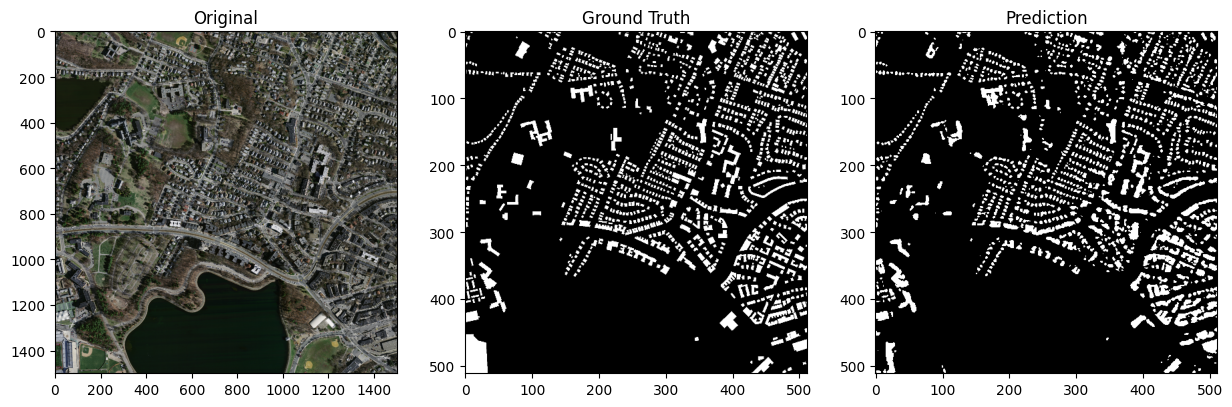

In [ ]:
IMAGE_PATH = "/content/drive/MyDrive/building_dataset/test_images/22828990_15.png"
MASK_PATH  = "/content/drive/MyDrive/building_dataset/test_masks/22828990_15.png"

show_result(IMAGE_PATH, MASK_PATH, model)

In [ ]:
def evaluate_model(model, dataloader):

    model.eval()

    total_iou = 0
    total_dice = 0
    total_acc = 0
    n = 0

    with torch.no_grad():

        for images, masks in dataloader:

            images = images.to(device)
            masks = masks.to(device)

            preds = model(images)
            preds = torch.sigmoid(preds)

            # Threshold
            preds_bin = (preds > 0.5).float()

            # Intersection
            intersection = (preds_bin * masks).sum()
            union = preds_bin.sum() + masks.sum() - intersection

            iou = intersection / (union + 1e-7)

            # Dice score
            dice = (2 * intersection) / (preds_bin.sum() + masks.sum() + 1e-7)

            # Pixel accuracy
            acc = (preds_bin == masks).float().mean()

            total_iou += iou.item()
            total_dice += dice.item()
            total_acc += acc.item()
            n += 1

    print("Validation Performance:")
    print("Mean IoU     :", total_iou / n)
    print("Mean Dice    :", total_dice / n)
    print("Pixel Accuracy:", total_acc / n)

In [ ]:
evaluate_model(model, val_loader)

Validation Performance:
Mean IoU     : 0.5411729940346309
Mean Dice    : 0.7017389791352409
Pixel Accuracy: 0.9251655851091657
